# 1. Seq2seq으로 번역기 만들기
이전 시간에 멋진 Sequence-to-Sequence 구조를 배웠습니다. 두 개의 RNN 모듈을 Encoder-Decoder 구조로 결합하여 사용하는 Seq2seq은 그야말로 혁신이었습니다.

Seq2seq이 번역기에 최적화되어 있는 만큼, 이번 코스에선 Seq2seq 기반 번역기를 직접 만들어보며 그 구조를 이해해보도록 하겠습니다. 또한 Attention 기법을 추가하여 성능을 높여보기도 할 거고요!

실습에는 영어-스페인어 말뭉치를 사용하지만 직접 하실 프로젝트는 한국어-영어 말뭉치를 사용할 것입니다. 그럼 시작합시다!

## 학습 내용
2. 데이터 전처리
- 필요한 데이터를 준비하고 전처리합니다.
3. 모델 설계
- Bahdanau Attention을 사용해서 코드 실습을 합니다.
4. 훈련하기
(1) Optimizer & Loss
Encoder-Decoder 구조를 정의합니다.
(2) train_step 구현하기
Loss를 계산한 후 반환하는 함수를 학습합니다.
(3) 훈련 시작하기
학습을 진행하고 시각화합니다.

## 학습 목표
데이터를 필요에 맞게 전처리할 수 있다.
Encoder-Decoder 구조를 이해할 수 있다.
Encoder-Decoder 구조를 다른 사람에게 설명할 수 있다.

In [1]:
!pip install sentencepiece

In [7]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker
import logging

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

fontpath = "c:/USERS/H11/APPDATA/LOCAL/MICROSOFT/WINDOWS/FONTS/NANUMBARUNGOTHIC.TTF"
fontprop = fm.FontProperties(fname=fontpath, size=12)
plt.rcParams["font.family"] = fontprop.get_name()

print(f"설정된 폰트: {fontprop.get_name()}")

설정된 폰트: NanumBarunGothic


# 2. 데이터 전처리
## 데이터 준비하기
먼저 프로젝트에 사용될 라이브러리를 import 하도록 합시다.

In [8]:
import os
import re
import urllib.request
import zipfile
import sentencepiece as spm
import pandas as pd

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

from tqdm import tqdm
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.__version__)

2.12.0+cu132


데이터를 다운로드하는 데에는 urllib.request.urlretrieve() 함수를 사용할 겁니다. urllib.request.urlretrieve()함수는 URL로부터 데이터를 다운받고, zip_ref.extractall() 함수는 폴더 내 압축된 파일들을 찾아 해제까지 알아서 할 수 있는 똑똑한 함수랍니다! 아래 소스를 실행해 데이터를 다운로드받아주세요.

In [9]:
dataset_dir = os.path.expanduser("work/s2s_translation/datasets")
os.makedirs(dataset_dir, exist_ok=True)

zip_path = os.path.join(dataset_dir, "spa-eng.zip")

if not os.path.exists(zip_path):
    print("데이터 다운로드 중...")
    url = "http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip"
    urllib.request.urlretrieve(url, zip_path)
    print("다운로드 완료!")

data_folder = os.path.join(dataset_dir, "spa-eng")
if not os.path.exists(data_folder):
    print("압축 해제 중...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(dataset_dir)
    print("압축 해제 완료!")

path_to_file = os.path.join(data_folder, "spa.txt")

print("데이터셋 디렉토리:", os.listdir(dataset_dir))

데이터 다운로드 중...
다운로드 완료!
압축 해제 중...
압축 해제 완료!
데이터셋 디렉토리: ['spa-eng', 'spa-eng.zip']


In [10]:
df = pd.read_csv(path_to_file, sep = "\t", names = ["eng", "spa"])
df.head()

,eng,spa
0,Go.,Ve.
1,Go.,Vete.
2,Go.,Vaya.
3,Go.,Váyase.
4,Hi.,Hola.


## 데이터 전처리: 정제하기
데이터는 \t 기호를 기준으로 영어와 스페인어가 병렬 쌍을 이루고 있습니다. 고로 \t 기호를 매개변수로 split() 함수를 호출하면 손쉽게 소스 문장과 타겟 문장을 분리할 수 있겠죠! 추가로 위 예시의 네 번째 문장을 보면 ¡ 같은 요상한 기호가 포함되어 있곤 합니다. 이 같은 특수문자는 불필요한 노이즈로 작용할 수 있기 때문에 정제 과정에서 삭제하도록 하겠습니다.

사실 스페인에서는 역 물음표(¿)와 역 느낌표(¡)를 일반적으로 사용합니다. 문장이 물음표나 느낌표로 끝난다면 해당 문장 맨 앞에 역으로 된 기호를 붙여준다고 해요. 이해를 돕기 위해 이상한 기호 취급을 하였으니 양해를 바랍니다!

정제는 아래 소스를 실행함으로써 진행할 수 있습니다.

In [11]:
def preprocess_sentence(sentence):
    sentence = sentence.lower().strip()

    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)
    sentence = re.sub(r"[^a-zA-Z?.!,]+", " ", sentence)

    sentence = sentence.strip()

    return sentence

print("슝~")

슝~


전처리 과정에서 문장의 시작 문자 <start>, 종료 문자 <end> 를 붙여주게 됩니다. 이 작업은 Encoder에 들어갈 입력 문장의 전처리에는 굳이 필요하지 않지만, Decoder의 입력 문장과 라벨로 사용할 출력 문장에는 꼭 필요하게 됩니다. 이전 렉처 노드에서 살펴보았듯, Decoder는 첫 입력으로 사용할 시작 토큰과 문장생성 종료를 알리는 끝 토큰이 반드시 필요하기 때문입니다.

원활한 학습을 위해 데이터는 상위 3만 개만 사용하도록 하겠습니다.

In [12]:
df = df[:30000]

df["eng"] = df["eng"].apply(preprocess_sentence)
df["spa"] = df["spa"].apply(lambda x: preprocess_sentence(x))

df.head()

,eng,spa
0,go .,ve .
1,go .,vete .
2,go .,vaya .
3,go .,v yase .
4,hi .,hola .


## 데이터 전처리: 토큰화
SentencePiece를 사용하려면 텍스트 파일이 필요합니다. 먼저 SentencePiece를 활용해 Tokenizer를 생성하고 테이터를 변환하겠습니다. 변환된 텐서를 80%의 훈련 데이터와 20%의 검증 데이터로 분리하세요! (Tokenizer의 단어 수는 자유롭게 진행하세요!)

In [13]:
df["eng"].to_csv("eng_corpus.txt", index=False, header=False, sep="\n", encoding="utf-8")
df["spa"].to_csv("spa_corpus.txt", index=False, header=False, sep="\n", encoding="utf-8")

print("파일 저장 완료: eng_corpus.txt, spa_corpus.txt")

파일 저장 완료: eng_corpus.txt, spa_corpus.txt


In [14]:
vocab_size = 3000
pad_id = 0
bos_id = 1
eos_id = 2
unk_id = 3

spm.SentencePieceTrainer.train(
    input = "eng_corpus.txt",
    model_prefix = "encoder_spm",
    vocab_size = vocab_size,
    pad_id = pad_id,
    bos_id = bos_id,
    eos_id = eos_id,
    unk_id = unk_id
)

spm.SentencePieceTrainer.train(
    input = "spa_corpus.txt",
    model_prefix = "decoder_spm",
    vocab_size = vocab_size,
    pad_id = pad_id,
    bos_id = bos_id,
    eos_id = eos_id,
    unk_id = unk_id
)

In [15]:
encoder_tokenizer = spm.SentencePieceProcessor()
encoder_tokenizer.load("encoder_spm.model")

decoder_tokenizer = spm.SentencePieceProcessor()
decoder_tokenizer.load("decoder_spm.model")

True

SentencePiece는 디코딩 과정에서 START_TOKEN과 END_TOKEN을 자동으로 변환해줍니다.

In [16]:
df

,eng,spa
0,go .,ve .
1,go .,vete .
2,go .,vaya .
3,go .,v yase .
4,hi .,hola .
...,...,...
29995,we ll go after we eat .,iremos despu s de comer .
29996,we ll live like kings .,viviremos como reyes .
29997,we ll lose everything .,lo perderemos todo .
29998,we ll meet right here .,nos encontraremos aqu mismo .


In [17]:
eng_sample = df["eng"][10000]
spa_sample = df["spa"][10000]
print(eng_sample)
print(spa_sample)

do you like fish ?
te gusta el pescado ?


문장을 인코딩한 뒤 START_TOKEN과 END_TOKEN을 붙여주겠습니다

In [18]:
enc_token = encoder_tokenizer.encode(eng_sample)
enc_token = [encoder_tokenizer.bos_id()] + enc_token + [encoder_tokenizer.eos_id()]
enc_token

[1, 27, 7, 39, 324, 9, 2]

위 토큰을 디코딩하면 어떻게 될까요?

In [19]:
enc_decoding = encoder_tokenizer.decode(enc_token)
enc_decoding

'do you like fish ?'

이처럼 디코딩 과정에선 START_TOKEN과 END_TOKEN 부분을 제외하고 디코딩을 합니다.

START_TOKEN과 END_TOKEN은 데이터셋을 생성하는 과정에서 추가해주도록 하겠습니다. 일반적으로 Padding 작업은 torch.nn.utils.rnn.pad_sequence와 같은 라이브러리를 사용하지만 여기에서는 과정을 좀 더 풀어서 보여드리도록 하겠습니다.

In [20]:
class TranslationDataset(Dataset):
    def __init__(self, data, encoder_tokenizer, decoder_tokenizer, max_len):
        self.data = data
        self.encoder_tokenizer = encoder_tokenizer
        self.decoder_tokenizer = decoder_tokenizer
        self.max_len = max_len
        self.pad_id = 0
        self.bos_id = 1
        self.eos_id = 2

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        src_text = self.data.iloc[idx]['eng']
        trg_text = self.data.iloc[idx]['spa']

        src_ids = self.encoder_tokenizer.encode(src_text)
        trg_ids = self.decoder_tokenizer.encode(trg_text)

        src_ids = src_ids[:self.max_len]

        # Decoder의 입력에는 START_TOKEN과 END_TOKEN을 추가해줍니다. 단, 최대 길이 제한을 적용시킵니다.
        trg_input = [self.bos_id] + trg_ids[:self.max_len - 2] + [self.eos_id]
        trg_label = trg_ids[:self.max_len - 1] + [self.eos_id]

        # 길이가 짧은 경우 PAD_TOKEN을 추가해줍니다.
        src_ids = src_ids + [self.pad_id] * (self.max_len - len(src_ids))
        trg_input = trg_input + [self.pad_id] * (self.max_len - len(trg_input))
        trg_label = trg_label + [self.pad_id] * (self.max_len - len(trg_label))

        return torch.tensor(src_ids), torch.tensor(trg_input), torch.tensor(trg_label)

In [21]:
train_ratio = 0.8  # 전체 길이의 80%
MAX_LEN = 30 # 임의의 값
BATCH_SIZE = 64

train_data = df.sample(frac=train_ratio, random_state=42)  # 80% 훈련 데이터
valid_data = df.drop(train_data.index)

train_data.reset_index(drop=True, inplace=True)
valid_data.reset_index(drop=True, inplace=True)

train_data = TranslationDataset(train_data, encoder_tokenizer, decoder_tokenizer, max_len=MAX_LEN)
validation_data = TranslationDataset(valid_data, encoder_tokenizer, decoder_tokenizer, max_len=MAX_LEN)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
validation_loader = DataLoader(validation_data, batch_size=BATCH_SIZE, shuffle=False)

In [22]:
for src, trg_input, trg_label in train_loader:
    print(src.shape, trg_input.shape, trg_label.shape)
    break

torch.Size([64, 30]) torch.Size([64, 30]) torch.Size([64, 30])


# 3. 모델 설계
이제부터 아래 그림처럼 각각 1개의 GRU을 갖는 Encoder-Decoder 구조를 설계할 겁니다.

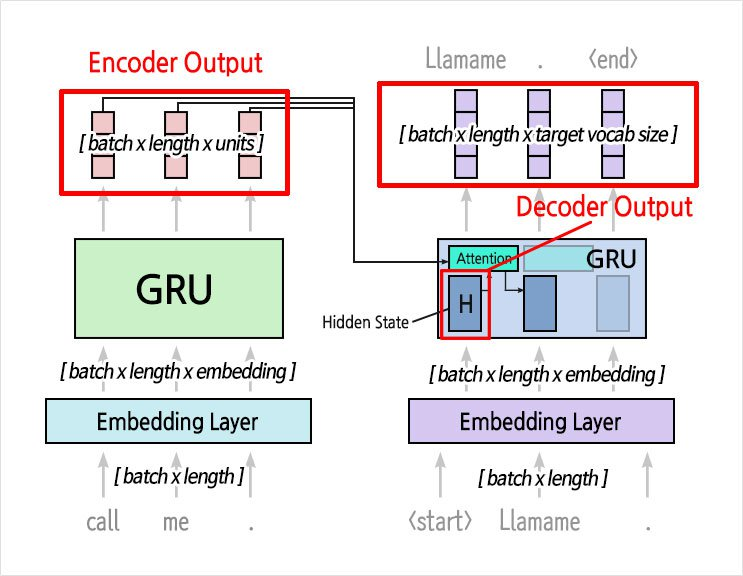

Encoder는 모든 Time-Step의 Hidden State를 출력으로 갖고, Decoder는 Encoder의 출력과 Decoder의 t-1 Step의 Hidden State로 Attention을 취하여 t Step의 Hidden State를 만들어 냅니다.

Decoder에서 t Step의 단어로 예측된 것을 실제 정답과 대조해 Loss를 구하고, 생성된 t Step의 Hidden State는 t+1 Step의 Hidden State를 만들기 위해 다시 Decoder에 전달됩니다.

여기서 't=1 일 때의 Hidden State는 어떻게 정의할 것인가?' 가 궁금하실 수 있는데요, 일반적으로 Encoder의 Final State를 Hidden State로 사용합니다.

Attention은 Bahdanau을 사용할 예정이며, 이는 이전 렉처 노드에서 실습한 코드를 가져다가 쓰도록 할게요.

## Q. 지금부터 활용해볼 Bahdanau Attention이 어떤 기능을 가진 기법인지 떠오르시나요?
기존 Seq2Seq 모델은 Encoder가 입력 문장의 모든 정보를 하나의 고정된 크기의 벡터(Final Hidden State)에 압축해서 Decoder로 넘겨줘야 했습니다. 이 때문에 문장이 길어지면 앞부분의 정보가 소실되는 문제가 있었습니다.

Bahdanau Attention은 이 문제를 다음과 같은 방식으로 해결합니다.

동적 컨텍스트 벡터 생성: Decoder가 매 Step마다 단어를 예측할 때, Encoder의 최종 State만 보는 것이 아니라 Encoder의 모든 Time-step 출력(Hidden States)을 다시 풀어서 봅니다.

유연한 집중(Attention): Decoder의 이전 시점 Hidden State와 Encoder의 모든 시점 Hidden State를 비교하여, "지금 예측해야 할 단어와 가장 연관성이 높은 입력 단어가 무엇인지" 점수(Attention Score)를 계산합니다.

가중합(Softmax): 계산된 점수를 바탕으로 소프트맥스를 취해 가중치를 만들고, 이를 Encoder 출력들과 곱해 매 시점마다 다양한 정보를 담은 컨텍스트 벡터(Context Vector)를 생성합니다.

In [23]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()

        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden: (batch_size, hidden_dim)
        # encoder_outputs: (src_len, batch_size, hidden_dim)

        src_len = encoder_outputs.shape[0]

        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)  # (batch_size, src_len, hidden_dim)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # (batch_size, src_len, hidden_dim)

        energy = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden))  # (batch_size, src_len, hidden_dim)
        attention = self.v(energy).squeeze(2)  # (batch_size, src_len)

        return nn.functional.softmax(attention, dim=1)  # (batch_size, src_len)

위 그림과 동일한 구조를 갖는 Encoder 클래스와 Decoder 클래스를 설계하고, 아래 소스를 실행해 답안과 같은 결과를 얻으세요.

In [24]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()

        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim)

    def forward(self, src):
        # src : (src_len, batch_size)
        embedded = self.embedding(src)  # embedded : (src_len, batch_size, emb_dim)
        outputs, hidden = self.rnn(embedded)  # outputs : (src_len, batch_size, hidden_dim)

        return outputs, hidden

In [25]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention):
        super(Decoder, self).__init__()

        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        # Decoder RNN에는 embedding만 입력
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        # 출력층에는 hidden state와 attention value가 결합되어 입력
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim)

    def forward(self, input, hidden, encoder_outputs):
        # input : (batch_size,)
        # hidden : (batch_size, hidden_dim)
        # encoder_outputs : (src_len, batch_size, hidden_dim)
        input = input.unsqueeze(0)  # input : (1, batch_size)
        embedded = self.embedding(input)  # embedded : (1, batch_size, emb_dim)

        # attention distribution을 계산합니다. decoder의 이전 hidden state, s_{t-1}와 encoder의 H가 입력됩니다.
        a = self.attention(hidden[-1], encoder_outputs)  # a : (batch_size, src_len)

        # H에 가중치를 부여해 attention value(Context vector) 계산
        a = a.unsqueeze(1)  # a : (batch_size, 1, src_len)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # encoder_outputs : (batch_size, src_len, hidden_dim)
        context = torch.bmm(a, encoder_outputs)  # context : (batch_size, 1, hidden_dim)
        context = context.permute(1, 0, 2)  # context : (1, batch_size, hidden_dim)

        output, hidden = self.rnn(embedded, hidden)

        # 출력층에서는 현재 hidden state와 context vector를 결합하여 예측값 생성
        output = output.squeeze(0)  # output : (batch_size, hidden_dim)
        context = context.squeeze(0)  # context : (batch_size, hidden_dim)
        prediction = self.fc_out(torch.cat((output, context), dim=1))  # (batch_size, output_dim)

        return prediction, hidden, a.squeeze(1)

In [26]:
class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg=None, max_len=30, bos_id = 1, eos_id=2):
        # 학습 모드에서는 trg_len 사용, 추론 모드에서는 max_len까지 동적 생성
        batch_size = src.shape[1]
        trg_vocab_size = self.decoder.fc_out.out_features

        # 조기 종료를 위해 tensor가 아닌 리스트 사용
        outputs = []

        # 시각화를 위해 attention 저장
        attentions = []

        # 인코더를 통해 context 생성
        encoder_outputs, hidden = self.encoder(src)

        if trg is not None:
            for t in range(0, trg.shape[0]):
                input = trg[t]
                output, hidden, attention = self.decoder(input, hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))

        else:
		    # inference에서는 target(정답)이 없기 때문에 sos_token을 생성해줍니다.
            input = torch.full((batch_size,), bos_id, dtype=torch.long, device=self.device)
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)

            for t in range(max_len):
                output, hidden, attention = self.decoder(input, hidden,  encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
                top1 = output.argmax(1)
                input = top1

                # 조기 종료 조건
                finished |= (top1 == eos_id)
                if finished.all():
                    break

        outputs = torch.cat(outputs, dim=0)  # (trg_len, batch_size, output_dim)
        attentions = torch.cat(attentions, dim=0)  # (trg_len, batch_size, src_len)

        return outputs, attentions

In [27]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

input_dim = len(encoder_tokenizer)
output_dim = len(decoder_tokenizer)
emb_dim = 256
hid_dim = 512

In [28]:
encoder = Encoder(input_dim, emb_dim, hid_dim).to(device)
attention = BahdanauAttention(hid_dim).to(device)
decoder = Decoder(output_dim, emb_dim, hid_dim, attention).to(device)
model = Seq2SeqAttention(encoder, decoder, device).to(device)

In [29]:
print(model)

Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(3000, 256)
    (rnn): GRU(256, 512)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(3000, 256)
    (rnn): GRU(256, 512)
    (fc_out): Linear(in_features=1024, out_features=3000, bias=True)
  )
)


코드를 실행하면 다음과 같은 형식의 결과가 나와야 합니다.

# 4. 훈련하기
지금까지는 Optimizer 안에 파라미터를 간편하게 입력했지만, Encoder-Decoder 구조의 경우 모델이 분리되어 파라미터를 각각 정의해줘야 합니다. 조금 불편하고 난감하게 다가올 수도 있지만 후에 더 멋진 연구를 하기 위한 발판이 되어 줄 테니 익숙해져 봅시다!

낯선 함수들이 지나치게 많이 등장할 수 있으니, 이번 코스에선 직접 구현을 하기보단 구현체를 먼저 보고 이해하는 방향으로 공부하도록 합시다!

## (1) Optimizer & Loss
가장 큰 줄기를 먼저 보고, 점점 더 들어가 보는 방식으로 진행해볼게요. 첫 순서는 Optimizer와 Loss입니다!

In [30]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id)

print("슝~")

슝~


Optimizer는 모델이 학습할 때에 정답을 찾아가는 방법 정도로 설명할 수 있는데, 일반적으론 Adam 외의 것을 사용하지 않으니 후에 실력이 더 늘어나고 나서 공부하시는 것을 권장합니다! 우선은 다른 배워야 할 것들이 산더미니까요...😅

nn.CrossEntropyLoss() 함수는 모델이 출력한 확률 분포와 (One-hot이 아닌) 정수 인덱스 답안을 비교해 Cross Entropy값을 구해줍니다. nn.NLLLoss()라면 [ 0.1, 0.2, 0.7 ] 과 One-hot 인코딩된 라벨 [0, 0, 1] 을 비교하여 점수를 채점하겠지만, nn.CrossEntropyLoss() 함수라면 [ 0.1, 0.2, 0.7 ] 과 정수 인덱스 답안 2 를 비교하여 점수를 채점하는 거죠.

## Q. 패딩(Padding) 과정을 진행하는 이유가 뭘까요?
1. 효율적인 배치(Batch) 처리
자연어 처리에서 모델은 문장을 한 개씩 처리하기보다 여러 문장을 묶은 '배치(Batch)' 단위로 동시에 처리합니다. 컴퓨터(특히 GPU)는 행렬 연산을 통해 이를 병렬로 계산하는데, 행렬 구조가 성립하려면 배치 내 모든 데이터의 크기(세로 크기와 가로 크기)가 완전히 동일해야 합니다.
사람마다, 문장마다 글자 수가 다르기 때문에 가장 긴 문장의 길이에 맞춰 빈 공간에 의미 없는 값(<PAD>)을 채워 넣어 사각형 모양의 고른 행렬을 만들어 주는 것입니다.

2. 하드웨어 가속(GPU) 최적화
GPU는 고정된 크기의 메모리 블록과 일정한 데이터 구조에서 연산할 때 최적의 성능을 냅니다. 만약 매번 입력되는 문장의 길이가 가변적이라면 행렬의 크기가 계속 바뀌어 연산 효율이 극도로 떨어지고 메모리를 효율적으로 쓰기 어렵습니다. 길이를 통일하면 메모리 할당과 연산 흐름이 안정화됩니다.

⚠️ 패딩을 쓸 때 주의할 점: Masking(마스킹)의 필요성
교재 내용에도 나와 있듯이, 패딩은 컴퓨터 연산을 위해 어쩔 수 없이 넣은 '의미 없는 공백'입니다.

만약 모델에게 아무런 처리를 해주지 않으면, 모델은 데이터의 상당 부분을 차지하는 <PAD> 토큰을 중요한 정보로 오해하거나, 주야장천 <PAD>만 출력하는 부작용(마치 객관식 시험에서 한 번호로 찍어도 높은 점수가 나오는 현상)이 발생할 수 있습니다.

그래서 실제 학습할 때는 Mask(마스크)를 활용하여 "이 부분은 패딩이니까 Loss(손실) 계산이나 어텐션 연산에서 제외해라" 하고 모델에게 알려주는 과정이 함께 들어가게 됩니다.



만약 모델에게 <PAD> 토큰이 패딩을 위한 토큰이라고 명시하지 않으면 모델은 데이터의 굉장히 많은 부분이 <PAD> 로 이뤄져 있다고 생각하게 됩니다. 쉽게 말해 유난히 같은 답이 많은 객관식 시험이라고나 할까요...? 어떤 시험이 한 번호로만 찍어도 80점 이상을 받을 수 있다면 그 시험은 공부를 절대 하지 않겠죠! 모델은 심지어 10,000개의 정답이 넘게 있는 고난도의 문제를 풀고 있기 때문에 패딩에 대한 처리를 해주지 않으면 <PAD> 토큰만을 생성할 확률이 굉장히 높아집니다.

이것은 종종 발생하는 문제라서 기억해두시면 좋아요. 이 문제를 방지하기 위해 mask 가 사용됩니다! mask 는 정답지에서 <PAD> 토큰을 찾아내어 그 부분에 대한 Loss는 구하지 않도록 하는 역할을 해주죠. equal() 함수에 정확히는 0 이 아닌 <PAD> 토큰의 인덱스를 전달하는 것이 맞지만 대부분의 경우는 0으로 패딩되기 때문에 편의상 0을 전달하여 처리하도록 하겠습니다.

## (2) train_step 구현하기
train_step()은 학습에 필요한 것을 모두 가져가 Loss를 계산한 후 반환하는 함수입니다. 먼저 구성을 보시죠!

In [32]:
def train_step(model, data_loader, optimizer, criterion, epoch):
    model.train()
    epoch_loss = 0

    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch+1}", leave=True)

    for src, trg_input, trg_label in progress_bar:
        # 모델의 입력 순서에 맞게 transpose 변환
        src = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)
        optimizer.zero_grad()

        outputs,_ = model(src, trg_input)
        
        # (trg_len, batch_size, output_dim)을 (batch_size * trg_len, output_dim)으로 변환
        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)

        optimizer.step()

        epoch_loss += loss.item()

        progress_bar.set_postfix(loss=loss.item())

    return epoch_loss / len(data_loader)

print("슝~")


슝~


코드를 좀 더 자세히 살펴봅시다.

train_step()의 학습 과정은 아래와 같습니다.

1. model.train()을 호출하여 모델을 학습 모드로 전환합니다.
2. optimizer.zero_grad()를 통해 이전 배치에서 계산된 기울기를 초기화합니다.
3. Encoder에 소스 문장을 전달해 컨텍스트 벡터인 enc_out 을 생성
4. t=0일 때, Decoder의 Hidden State는 Encoder의 Final State로 정의. h_dec = enc_hidden Encoder 처리
5. <start> 문장과 enc_out, Hidden State를 기반으로 다음 단어(t=1)를 예측. predictions
6. 예측된 단어와 정답 간의 Loss를 구한 후, t=1의 정답 단어를 다음 입력으로 사용 (예측 단어 사용X)  
반복!  
코드를 한 줄 한 줄 살피면 이해가 어려운 라인은 없을 거예요.  

## (3) 훈련 시작하기
다음 순서는 본격적으로 훈련을 시작하는 부분입니다! (훈련 시간은 약 15분 정도 소요 됩니다.)

In [33]:
%%time

EPOCHS = 10

for epoch in range(EPOCHS):
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}')

Epoch 1: 100%|██████████| 375/375 [00:38<00:00,  9.83it/s, loss=2.04]


Epoch 1/10, Train Loss: 3.0886


Epoch 2: 100%|██████████| 375/375 [00:37<00:00, 10.08it/s, loss=1.18]


Epoch 2/10, Train Loss: 1.5507


Epoch 3: 100%|██████████| 375/375 [00:37<00:00, 10.04it/s, loss=0.893]


...

Epoch 8/10, Train Loss: 0.2188


Epoch 9: 100%|██████████| 375/375 [00:38<00:00,  9.82it/s, loss=0.245]


Epoch 9/10, Train Loss: 0.2070


Epoch 10: 100%|██████████| 375/375 [00:38<00:00,  9.65it/s, loss=0.298]

Epoch 10/10, Train Loss: 0.2048
CPU times: total: 6min 8s
Wall time: 6min 17s


먼저 tqdm은 훈련의 진행 과정을 한눈에 볼 수 있게 해주는 라이브러리입니다. 사용법은 위 예제만 봐도 이해가 갈 정도로 정말 간단하니 웬만하면 활용하시는 것을 추천해 드려요! # tqdm이 붙은 라인은 모두 출력에 관련된 내용이니 설명을 생략하겠습니다. 궁금하신 분들은 아래 github을 참고하시길 바라요!

tqdm/tqdm
먼저 EPOCHS = 10 만큼 반복하는 루프에 진입한 후, 각 배치의 시작 인덱스를 idx_list 배열에 저장합니다. 그리고 모델이 학습을 원활하게 할 수 있도록 데이터를 섞어줘야 하는데요, 인덱스를 섞어서 처리할 겁니다. 순차적인 인덱스로 데이터를 불러오는 게 아닌 랜덤한 인덱스로 데이터를 불러오는 것은 데이터를 섞는 것과 동일한 효과를 가져오겠죠!

그 후에 각 미니배치를 train_step() 함수에서 학습합니다. train_step()은 학습에 필요한 것은 모두 가져가 Loss를 계산한 후 반환하는 함수였죠!

이번 기회에 Encoder-Decoder 구조의 학습 방법을 마스터하세요! optimizer와 loss, train_step()까지 정의한 후 훈련을 시작하면 아래와 같은 결과를 확인할 수 있습니다.

실습하기
이제 직접 실습해 볼까요?

Step 1에서 분리한 Validation Set을 사용하는 eval_step() 함수를 정의하세요! 그리고 train_step() 을 마친 후, 곧이어 eval_step() 을 진행하도록 소스를 수정하세요! 결과는 아래와 같은 형태가 되어야 합니다.

(주의! Evaluation 중에는 모델이 학습을 해서는 안 됩니다!)

In [34]:
def eval_step(model, data_loader, optimizer, criterion):
    model.eval()
    total_loss = 0

    for src, trg_input, trg_label in data_loader:
        # 모델의 입력 순서에 맞게 transpose 변환
        src = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)

        outputs,_ = model(src, trg_input)
        
        # (trg_len, batch_size, output_dim)을 (batch_size * trg_len, output_dim)으로 변환
        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)

        total_loss += loss.item()

    return total_loss / len(data_loader)

print("슝~")

슝~


In [35]:
%%time

EPOCHS = 20

for epoch in range(EPOCHS):
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    valid_loss = eval_step(model, validation_loader, optimizer, criterion)
    print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}')

Epoch 1: 100%|██████████| 375/375 [00:37<00:00,  9.89it/s, loss=0.292] 


Epoch 1/20, Train Loss: 0.1995, Validation Loss: 1.7760


Epoch 2: 100%|██████████| 375/375 [00:37<00:00,  9.98it/s, loss=0.191] 


Epoch 2/20, Train Loss: 0.1966, Validation Loss: 1.7788


Epoch 3: 100%|██████████| 375/375 [00:38<00:00,  9.67it/s, loss=0.29]  


...

Epoch 18/20, Train Loss: 0.1719, Validation Loss: 1.9499


Epoch 19: 100%|██████████| 375/375 [00:36<00:00, 10.14it/s, loss=0.248] 


Epoch 19/20, Train Loss: 0.1717, Validation Loss: 1.9604


Epoch 20: 100%|██████████| 375/375 [00:37<00:00, 10.04it/s, loss=0.2]   


Epoch 20/20, Train Loss: 0.1692, Validation Loss: 1.9711
CPU times: total: 13min 39s
Wall time: 13min 59s


훈련이 완료된 모델은 아래 소스를 실행해 번역 성능을 평가할 수 있어요. Attention Map을 시각화하는 것은 보너스!

In [ ]:
def evaluate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=30):
    model.eval()

    sentence = preprocess_sentence(sentence)
    src_ids = encoder_tokenizer.encode(sentence)
    src_ids = src_ids[:max_len]
    src_ids = src_ids + [0] * (max_len - len(src_ids))  # 패딩 추가
    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)  # (src_len, 1)

    with torch.no_grad():
        outputs, attentions = model(src_tensor, max_len=max_len)

    result = [decoder_tokenizer.decode([token.item()]) for token in outputs.argmax(2).squeeze(1)]

    if "<end>" in result:
        result = result[:result.index("<end>")]

    return result, sentence, attentions.squeeze(1).cpu().numpy()

In [ ]:
def plot_attention(attention, sentence, predicted_sentence):
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.matshow(attention, cmap='viridis')

    fontdict = {'fontsize': 14}

    ax.set_xticks(range(len(sentence)))
    ax.set_xticklabels(sentence, fontdict=fontdict, rotation=90)

    ax.set_yticks(range(len(predicted_sentence)))
    ax.set_yticklabels(predicted_sentence, fontdict=fontdict)

    plt.show()

In [ ]:
def translate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=30):
    result, sentence, attention = evaluate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len)

    print('Input: %s' % (sentence))
    print('Predicted translation: {}'.format(result))

    # Attention 크기 조정 (trg_len, src_len)
    attention = attention[:len(result), :len(sentence.split())]

    plot_attention(attention, sentence.split(), result)

In [ ]:
translate("The most powerful man all over the world.", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

In [ ]:
translate("May I help you?", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

In [ ]:
# 실행 예제
translate("Can I have some coffee?", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

아래와 같은 맵이 나오면 성공입니다.
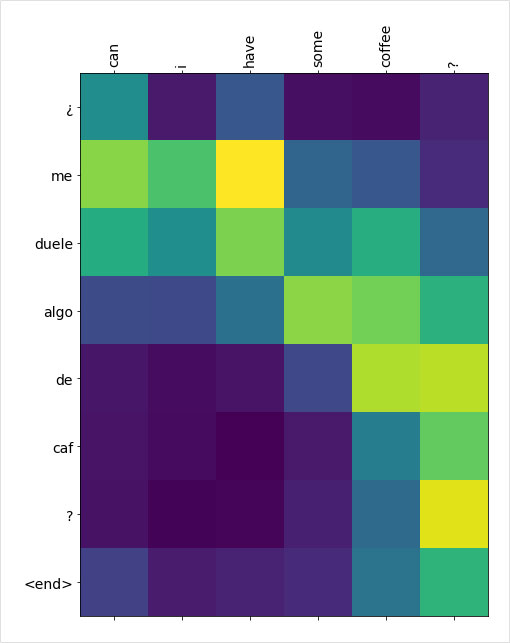

